# Brain MRI Tumor Classification

**Two-approach pipeline:**
1. **Approach 1** – ResNet50 as a fixed feature extractor → SVM classifier
2. **Approach 2** – End-to-end ResNet50 fine-tuning (Deep Learning classifier)


## 0. Setup: Mount Drive & Extract Dataset

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
import zipfile
import os

zip_path     = "/content/drive/MyDrive/BrainMRI.zip"
extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Done extracting!")


Done extracting!


In [3]:
train_dir = "/content/dataset/Training"
test_dir  = "/content/dataset/Testing"


## 1. Data Generators

We define **two** sets of generators:
- **Augmented** generators (`train_data`, `val_data`, `test_data`) used for DL training (Approach 2).
- A **non-augmented** generator (`train_data_noaug`) used for feature extraction (Approach 1),
  with `shuffle=False` so that extracted features stay aligned with labels.


In [4]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet50 import preprocess_input

IMG_SIZE   = 224
BATCH_SIZE = 32

# ── Augmented generators (used for Approach 2 DL training) ────────────────
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=25,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)

test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False   # MUST be False for evaluation alignment
)

# ── Non-augmented train generator (used for Approach 1 SVM) ───────────────
noaug_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_data_noaug = noaug_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False   # MUST be False so features align with labels
)


Found 4480 images belonging to 4 classes.
Found 1120 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.
Found 5600 images belonging to 4 classes.


In [5]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

y_train_labels = train_data.classes

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_labels),
    y=y_train_labels
)
class_weights = dict(enumerate(class_weights))
print("Class weights:", class_weights)

# NOTE: If the dataset is balanced (all weights ≈ 1.0), class_weight can be
# omitted from model.fit(). We keep it here for transparency and robustness.


Class weights: {0: np.float64(1.0), 1: np.float64(1.0), 2: np.float64(1.0), 3: np.float64(1.0)}


---
## Approach 2 (End-to-End): ResNet50 Fine-tuned Deep Learning Classifier

> **Run order note:** Approach 2 is trained first because Approach 1 reuses
> the fine-tuned ResNet50 backbone to extract richer features for the SVM.
> If you want a truly independent SVM baseline, swap the order and use
> ImageNet weights directly in the feature extractor.


### 2.1 Build Model & Phase 1 Training (frozen backbone)

In [6]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Phase 1: Freeze entire backbone — only the custom head is trained
for layer in base_model.layers:
    layer.trainable = False

# Custom classification head
x      = base_model.output
x      = GlobalAveragePooling2D()(x)
x      = BatchNormalization()(x)
x      = Dense(512, activation='relu')(x)
x      = Dropout(0.5)(x)
x      = Dense(256, activation='relu')(x)
x      = Dropout(0.3)(x)
output = Dense(4,   activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=Adam(1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

phase1_callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=5,
                  restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_phase1.keras', monitor='val_accuracy',
                    save_best_only=True, verbose=1)
]

history1 = model.fit(
    train_data,
    validation_data=val_data,
    epochs=15,
    callbacks=phase1_callbacks
    # class_weight=class_weights  # Uncomment if dataset is imbalanced
)


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Epoch 1/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 449ms/step - accuracy: 0.5089 - loss: 1.3328
Epoch 1: val_accuracy improved from None to 0.83304, saving model to best_phase1.keras

Epoch 1: finished saving model to best_phase1.keras
140/140 ━━━━━━━━━━━━━━━━━━━━ 104s 627ms/step - accuracy: 0.6337 - loss: 0.9697 - val_accuracy: 0.8330 - val_loss: 0.4861
Epoch 2/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 454ms/step - accuracy: 0.7781 - loss: 0.6004
Epoch 2: val_accuracy improved from 0.83304 to 0.87054, saving model to best_phase1.keras

Epoch 2: finished saving model to best_phase1.keras
140/140 ━━━━━━━━━━━━━━━━━━━━ 81s 580ms/step - accuracy: 0.7857 - loss: 0.5731 - val_accuracy: 0.8705 - val_loss: 0.3598
Epoch 3/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 456ms/step - accuracy: 0.8091 - loss: 0.5115
Epoch 3: val_accuracy improved from 0.87054 to 0.87232, saving model to best_phase1.keras

Epoch 3: finished saving model to best_phase1.keras
140/140 ━━━━━━━━━━

### 2.2 Phase 2 Training (fine-tune top layers)

In [7]:
# Unfreeze the last 60 layers of ResNet50 for fine-tuning
for layer in base_model.layers[-60:]:
    layer.trainable = True

model.compile(
    optimizer=Adam(1e-5),   # Much lower LR for fine-tuning
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# FIX: ReduceLROnPlateau patience (4) < EarlyStopping patience (8)
#      so LR reduction can trigger before training stops.
#      The original notebook had them reversed (10 vs 8), meaning
#      ReduceLROnPlateau could never fire before EarlyStopping.
phase2_callbacks = [
    EarlyStopping(monitor='val_loss', patience=8,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3,
                      patience=4, verbose=1),
    ModelCheckpoint('best_phase2.keras', monitor='val_loss',
                    save_best_only=True, verbose=1)
]

history2 = model.fit(
    train_data,
    validation_data=val_data,
    epochs=40,
    callbacks=phase2_callbacks
)


Epoch 1/40
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 478ms/step - accuracy: 0.8836 - loss: 0.3161
Epoch 1: val_loss improved from None to 0.21549, saving model to best_phase2.keras

Epoch 1: finished saving model to best_phase2.keras
140/140 ━━━━━━━━━━━━━━━━━━━━ 121s 647ms/step - accuracy: 0.8895 - loss: 0.2883 - val_accuracy: 0.9223 - val_loss: 0.2155 - learning_rate: 1.0000e-05
Epoch 2/40
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 464ms/step - accuracy: 0.9103 - loss: 0.2301
Epoch 2: val_loss improved from 0.21549 to 0.18661, saving model to best_phase2.keras

Epoch 2: finished saving model to best_phase2.keras
140/140 ━━━━━━━━━━━━━━━━━━━━ 84s 600ms/step - accuracy: 0.9138 - loss: 0.2303 - val_accuracy: 0.9286 - val_loss: 0.1866 - learning_rate: 1.0000e-05
Epoch 3/40
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 462ms/step - accuracy: 0.9249 - loss: 0.2036
Epoch 3: val_loss improved from 0.18661 to 0.16181, saving model to best_phase2.keras

Epoch 3: finished saving model to best_phase2.keras
140/140 ━━━━━━━━━━━━━━━━━

### 2.3 Evaluate Approach 2 (DL)

In [14]:
import numpy as np
from sklearn.metrics import classification_report, accuracy_score

# FIX: Always reset the generator before predicting to ensure
#      predictions are in the same order as generator.classes.
test_data.reset()

preds     = model.predict(test_data)
y_pred_dl = np.argmax(preds, axis=1)
y_true    = test_data.classes

dl_acc = accuracy_score(y_true, y_pred_dl)
print("Approach 2 - DL Accuracy:", dl_acc)
print(classification_report(
    y_true, y_pred_dl,
    target_names=list(test_data.class_indices.keys())
))


50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 147ms/step
Approach 2 - DL Accuracy: 0.9375
              precision    recall  f1-score   support

      glioma       0.98      0.81      0.89       400
  meningioma       0.88      0.94      0.91       400
     notumor       0.94      1.00      0.97       400
   pituitary       0.95      1.00      0.97       400

    accuracy                           0.94      1600
   macro avg       0.94      0.94      0.94      1600
weighted avg       0.94      0.94      0.94      1600



---
## Approach 1: ResNet50 as Fixed Feature Extractor → SVM Classifier

We reuse the **fine-tuned** ResNet50 backbone from Approach 2 as a feature
extractor, feeding its GlobalAveragePooling2D output into a Support Vector
Machine (SVM). This gives the SVM access to richer, task-adapted features
instead of raw ImageNet embeddings.


### 3.1 Build Feature Extractor

In [9]:
from tensorflow.keras.models import Model as KerasModel

# FIX: Extract features from the GlobalAveragePooling2D layer of the
#      TRAINED model — not a new standalone layer on top of base_model.output.
#      A new layer would be randomly initialised and ignore the trained head.
#      We identify the layer by name for clarity and robustness.
gap_layer         = model.get_layer('global_average_pooling2d')
feature_extractor = KerasModel(inputs=model.input, outputs=gap_layer.output)

print("Feature extractor output shape:", feature_extractor.output_shape)


Feature extractor output shape: (None, 2048)


### 3.2 Extract Features from Training and Test Sets

In [10]:
def extract_features(generator, extractor):
    """Iterate over all batches of a generator and collect deep features."""
    features, labels = [], []
    for i in range(len(generator)):
        x, y = generator[i]
        f = extractor.predict(x, verbose=0)
        features.append(f)
        labels.append(y)
    return np.vstack(features), np.vstack(labels)

# FIX: Use the non-augmented, shuffle=False train generator so that
#      feature vectors and labels stay perfectly aligned.
#      The original notebook created this generator inside two separate
#      cells, causing confusion and a potential duplicate.
test_data.reset()  # Ensure test generator starts from the beginning

X_train_raw, y_train_raw = extract_features(train_data_noaug, feature_extractor)
X_test_raw,  y_test_raw  = extract_features(test_data,        feature_extractor)

# Convert one-hot encoded labels to integer class indices
y_train = np.argmax(y_train_raw, axis=1)
y_test  = np.argmax(y_test_raw,  axis=1)

print("Train features shape:", X_train_raw.shape)
print("Test  features shape:", X_test_raw.shape)


Train features shape: (5600, 2048)
Test  features shape: (1600, 2048)


### 3.3 Scale Features & Train SVM

In [15]:
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# FIX (two bugs fixed here):
#   1. The original notebook had a cell that arbitrarily subsampled to 3 000
#      examples with no justification — removed. All training data is used.
#   2. The scaler was fit TWICE (once on subsampled data, once on full data).
#      We now fit it ONCE on X_train and only transform X_test.
scaler          = StandardScaler()
X_train_scaled  = scaler.fit_transform(X_train_raw)  # fit on train only
X_test_scaled   = scaler.transform(X_test_raw)       # transform test (no re-fit)

svm = SVC(
    kernel='rbf',
    C=10,
    gamma='scale',
    class_weight='balanced'
)

svm.fit(X_train_scaled, y_train)
y_pred_svm = svm.predict(X_test_scaled)


### 3.4 Evaluate Approach 1 (SVM)

In [16]:
svm_acc = accuracy_score(y_test, y_pred_svm)
print("Approach 1 - SVM Accuracy:", svm_acc)
print(classification_report(
    y_test, y_pred_svm,
    target_names=list(test_data.class_indices.keys())
))


Approach 1 - SVM Accuracy: 0.944375
              precision    recall  f1-score   support

      glioma       0.99      0.80      0.89       400
  meningioma       0.88      0.99      0.93       400
     notumor       0.94      1.00      0.97       400
   pituitary       0.99      0.99      0.99       400

    accuracy                           0.94      1600
   macro avg       0.95      0.94      0.94      1600
weighted avg       0.95      0.94      0.94      1600



---
## 4. Comparison: Approach 1 (SVM) vs Approach 2 (End-to-End DL)


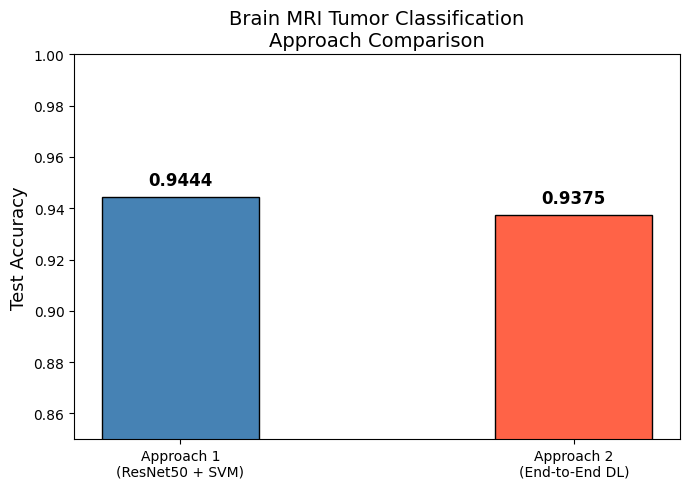


Approach 1 - SVM Accuracy : 0.9444
Approach 2 - DL  Accuracy : 0.9375

Better approach: SVM (Approach 1)


In [17]:
import matplotlib.pyplot as plt

models_names = ['Approach 1\n(ResNet50 + SVM)', 'Approach 2\n(End-to-End DL)']
acc          = [svm_acc, dl_acc]
colors       = ['steelblue', 'tomato']

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(models_names, acc, color=colors, width=0.4, edgecolor='black')
ax.set_ylim(0.85, 1.0)
ax.set_ylabel('Test Accuracy', fontsize=13)
ax.set_title('Brain MRI Tumor Classification\nApproach Comparison', fontsize=14)

for bar, a in zip(bars, acc):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.003,
        f'{a:.4f}',
        ha='center', va='bottom', fontsize=12, fontweight='bold'
    )

plt.tight_layout()
plt.savefig('approach_comparison.png', dpi=150)
plt.show()

print(f"\nApproach 1 - SVM Accuracy : {svm_acc:.4f}")
print(f"Approach 2 - DL  Accuracy : {dl_acc:.4f}")
winner = 'SVM (Approach 1)' if svm_acc >= dl_acc else 'End-to-End DL (Approach 2)'
print(f"\nBetter approach: {winner}")
